In [7]:
# essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# sklearn librabries (Weeks 5-7)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, RFECV
# sklearn libraies/functions (NEW)
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import cross_validate


# Decision Tree 
* Decision tree are a type of supervised machine learning algorithm that are used for both classification and regression tasks. 
* A decision tree starts with a root node and splits the data on feature threshold to minimise error 

In [14]:
import os

# Get current working directory
cwd = os.getcwd()

print("Current Working Directory:", cwd)
# Define the new path you want to change to
new_path = "C:/Users/vansh/Downloads" 

# Change the working directory
os.chdir(new_path)


Current Working Directory: C:\Users\vansh\Downloads


In [16]:
# Load the same Boston Dataset
h=pd.read_csv("boston.csv")
X,y=h.drop("price",axis=1),h["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101, shuffle=True) 



In [20]:
# Linear Regression 
LR = LinearRegression()
LR.fit(X_train,y_train)
print("MSE (Train):", MSE(y_train,LR.predict(X_train)).round(3))
print("MSE (Test):",MSE(y_test,LR.predict(X_test)).round(3))


MSE (Train): 20.599
MSE (Test): 34.783


In [24]:
# Under Fitting
# As MSE is higher on test and the difference is huge/

In [22]:
# Decision Tree 
DTR= DecisionTreeRegressor(random_state=101,max_depth=None)
DTR.fit(X_train,y_train)
print("MSE:", MSE(y_train, DTR.predict(X_train)).round(3))
print("MSE:", MSE(y_test, DTR.predict(X_test)).round(3))


MSE: 0.0
MSE: 10.605


In [26]:
# Over fitting as learned all the data ( MSE on train is 0) 


# Random Forest 

In [29]:
# Random forest is a collection of multiple decision trees, where each tree is trained on a random subset of data. 

In [33]:
RFR = RandomForestRegressor(random_state=101,n_estimators=100,max_depth=None)
RFR.fit(X_train,y_train)
print("MSE(Train):", MSE(y_train, RFR.predict(X_train)).round(3))
print("MSE(Test):", MSE(y_test, RFR.predict(X_test)).round(3))


MSE(Train): 1.648
MSE(Test): 11.013


# Gradient Boosting 

In [38]:
# Gradient boosting learns from it mistakes, it trains a series of decision tree
# It starts from the weakest one, calculate the errors ( does this step till number of estimators defined) 
GBR= GradientBoostingRegressor(random_state=101,learning_rate=0.1,n_estimators=100,max_depth=3)
GBR.fit(X_train, y_train)
print("MSE train :", MSE(y_train, GBR.predict(X_train)).round(3))
print("MSE test:", MSE(y_test, GBR.predict(X_test)).round(3))


MSE train : 1.94
MSE test: 8.192


In [45]:
# 📌 MSE Summary: Model Comparison

# 🔹 Linear Regression
# Train MSE: 20.60 | Test MSE: 34.78
# ➤ Underfitting: Too simple, high test error.

# 🔹 Decision Tree
# Train MSE: 0.00 | Test MSE: 10.61
# ➤ Overfitting: Memorized training data, poor generalization.

# 🔹 Random Forest
# Train MSE: 1.65 | Test MSE: 11.01
# ➤ Better generalization: Reduces overfitting by averaging trees.

# 🔹 Gradient Boosting
# Train MSE: 1.94 | Test MSE: 8.19
# ➤ Strong performance: Learns from mistakes iteratively.

# ✅ Ideal case: Low train/test MSE with a small gap → Good generalization.


In [47]:
# Applying the K FOLD CV

In [49]:
rcv=RepeatedKFold(n_splits=10,n_repeats=3,random_state=101)
rcv

RepeatedKFold(n_repeats=3, n_splits=10, random_state=101)

In [51]:
# get mse 
# get mse (-nmse)
mse1 = pd.DataFrame(-cross_val_score(LR, X, y, scoring='neg_mean_squared_error', cv=rcv), columns=['LR'])
mse2 = pd.DataFrame(-cross_val_score(DTR, X, y, scoring='neg_mean_squared_error', cv=rcv), columns=['DT'])
mse3 = pd.DataFrame(-cross_val_score(RFR, X, y, scoring='neg_mean_squared_error', cv=rcv), columns=['RF'])
mse4 = pd.DataFrame(-cross_val_score(GBR, X, y, scoring='neg_mean_squared_error', cv=rcv), columns=['GB'])

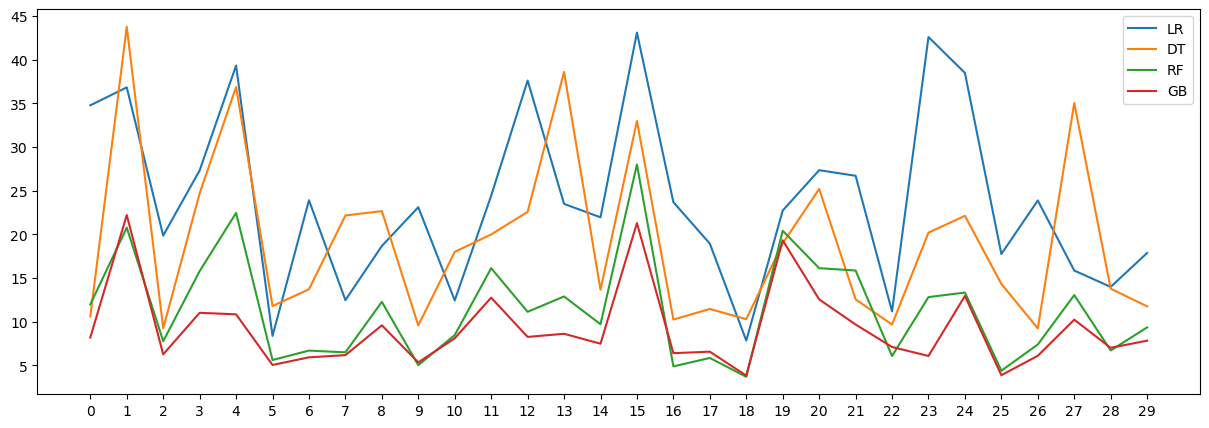

In [53]:
# line chart on two sets of mse's
mse=pd.concat([mse1,mse2,mse3,mse4], axis=1)
mse.plot(kind='line', figsize=(15,5), xticks=range(30));

In [55]:
mse.agg(['mean','std']).round(3)

,LR,DT,RF,GB
mean,23.889,19.195,11.373,9.222
std,10.017,9.805,6.047,4.672


**Comments**

* Overall, GB is the best (lowest mean & std), followed by RF, then DT & LR.
* These results are based on the default setting (except for random_state=101).

In [60]:
# Choosing the optimal max_depth and other hyperparameters


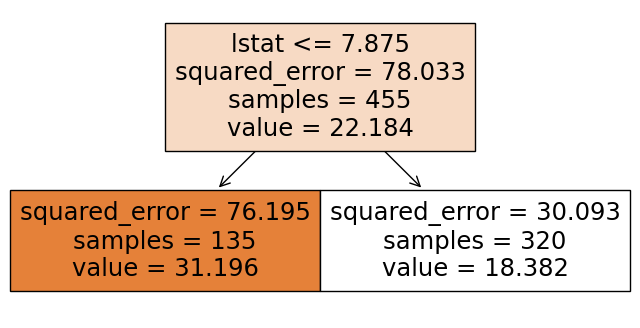

In [62]:
# visualize the tree 
# let's do a small tree with max_depth=2 & various max_leaf_nodes=2,3,4 (number of terminal nodes)
DTR = DecisionTreeRegressor(random_state=101, max_depth=2, max_leaf_nodes=2)
DTR.fit(X_train, y_train)
fig = plt.figure(figsize=(8,4))
tree.plot_tree(DTR, feature_names=X.columns, filled=True);

In [64]:
# 📌 Interpretation of Decision Tree Root Node

# 🧮 Condition: lstat <= 7.875
# - Meaning: Is the lower-status population in the area less than or equal to 7.875%?

# 📊 Node Stats:
# - Samples: 455 total data points
# - Value: 22.184 → Average house price before the split (likely in $1000s)
# - Squared Error: 78.033 → Variance in house prices at this node

# 🌳 After the Split:

# ✅ Left Node (True: lstat <= 7.875)
# - Samples: 135
# - Value: 31.196 → Higher average house price
# - Squared Error: 76.195 → High variance
# - Interpretation: Wealthier areas (low lstat) with higher home values

# ❌ Right Node (False: lstat > 7.875)
# - Samples: 320
# - Value: 18.382 → Lower average house price
# - Squared Error: 30.093 → Lower variance
# - Interpretation: Poorer areas (high lstat) with lower home values

# 🧠 Insight:
# - lstat is a strong predictor of house prices.
# - The model learns that lower lstat → higher prices, and higher lstat → lower prices.
# - This split reduces prediction error and increases model accuracy.


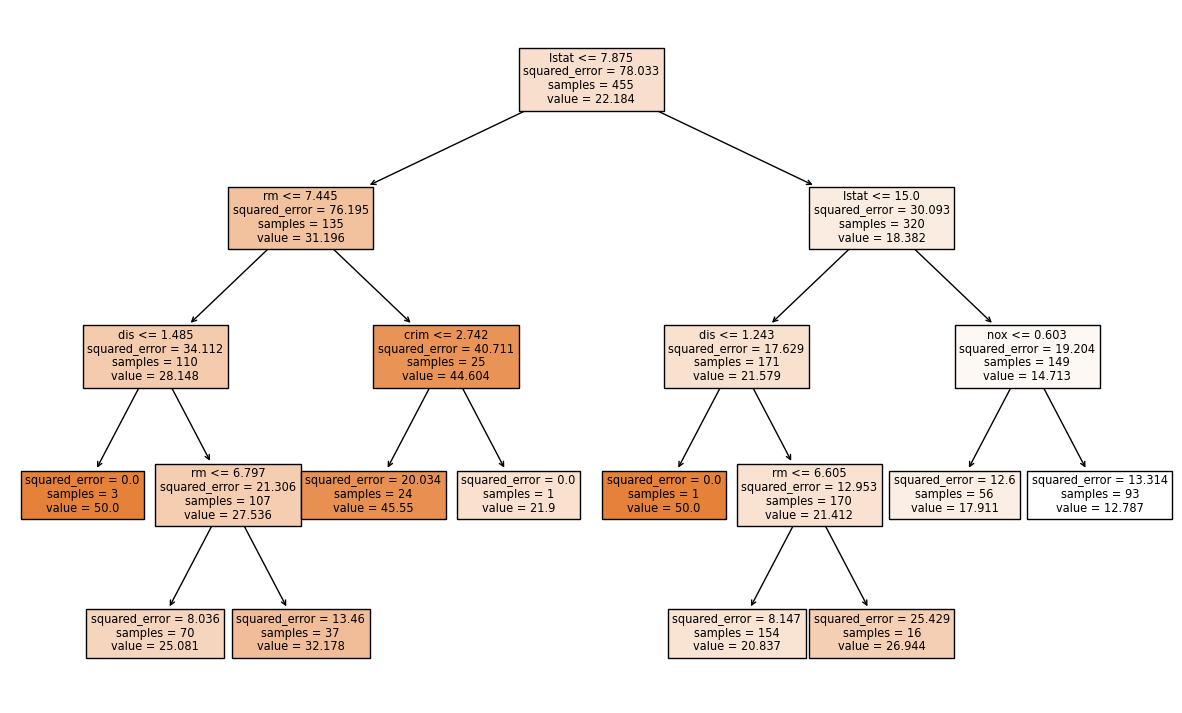

In [68]:
# visualize the tree (let's do a bigger tree: max_depth=5, max_leaf_nodes=10)
DTR = DecisionTreeRegressor(random_state=101, max_depth=5, max_leaf_nodes=10)
DTR.fit(X_train, y_train)
fig = plt.figure(figsize=(15,9))
colors = ['crimson', 'dodgerblue']
tree.plot_tree(DTR,feature_names=X.columns,filled=True);

In [70]:
# without restriction (max_depth=None)
DTR = DecisionTreeRegressor(random_state=101, max_depth=None, max_leaf_nodes=None)
DTR.fit(X_train, y_train)
# get the depth of the decision tree
print("depth:", DTR.get_depth())
print("total noumber of leaves", DTR.get_n_leaves())

depth: 21
total noumber of leaves 429


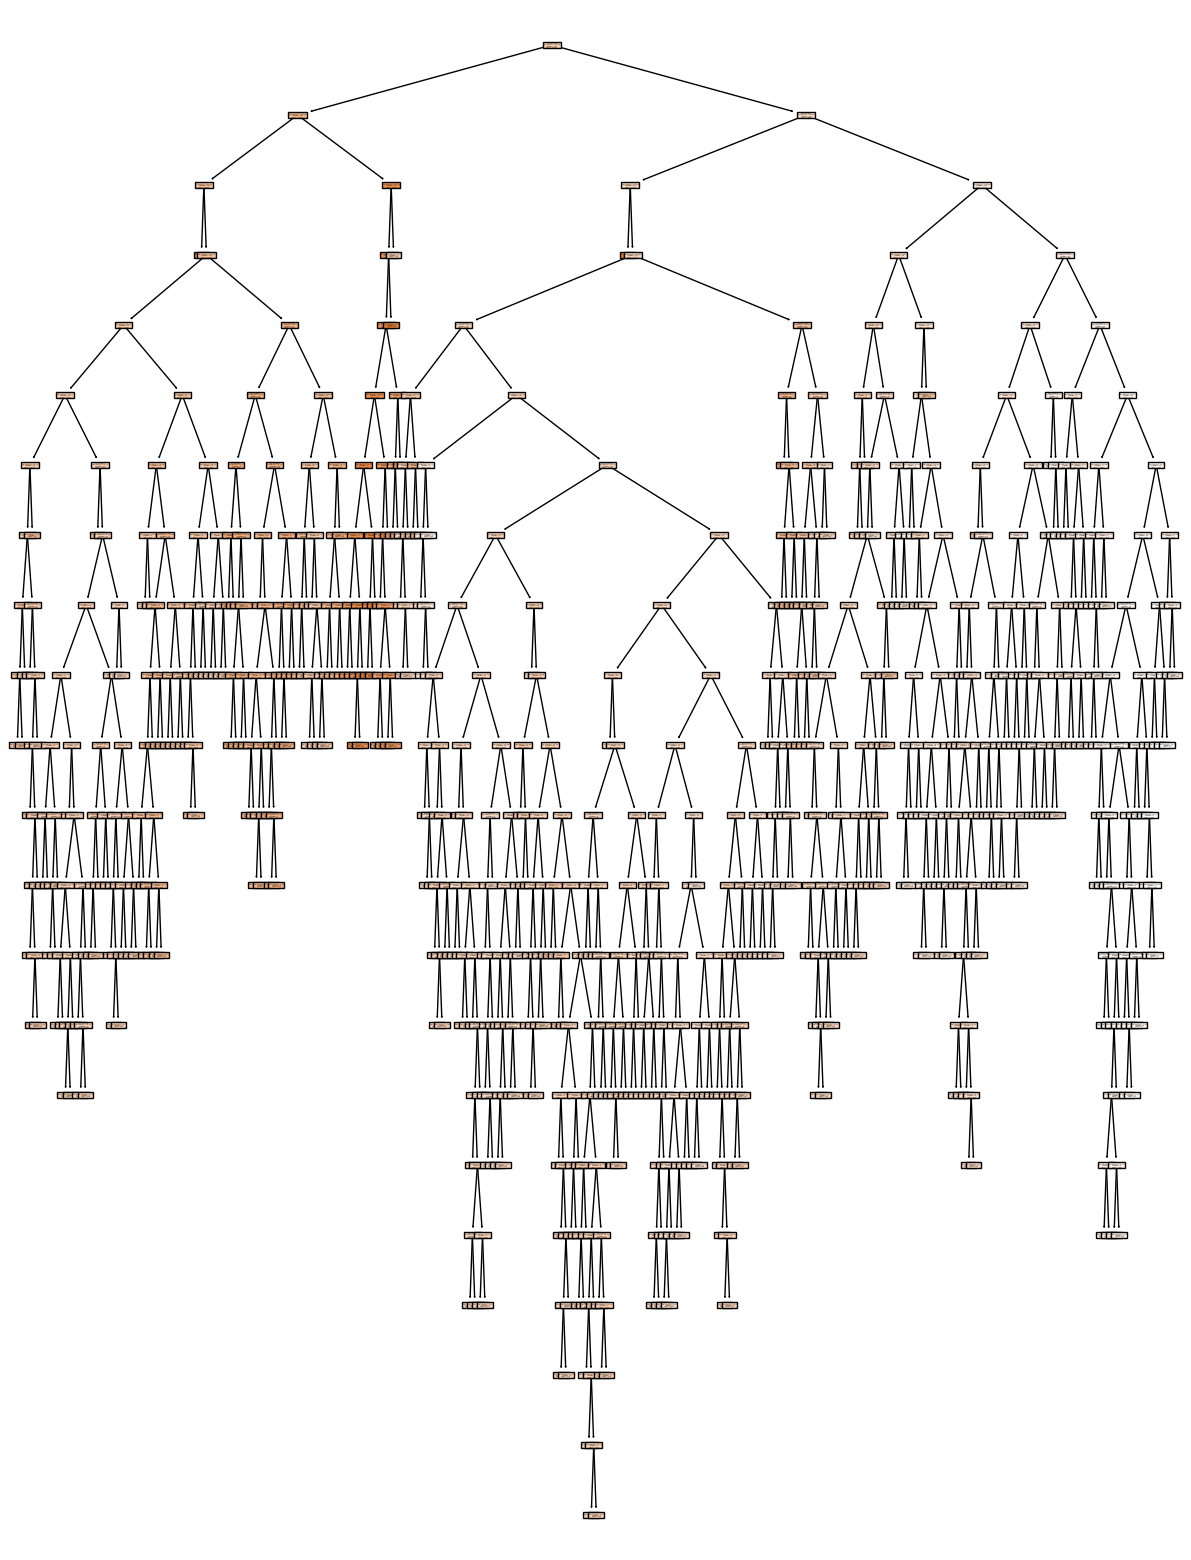

In [72]:
# visualize the tree (max_depth=None)
# might take a while to run....
DTR = DecisionTreeRegressor(random_state=101, max_depth=None)
DTR.fit(X_train, y_train)
fig = plt.figure(figsize=(15,20))
tree.plot_tree(DTR,feature_names=X.columns,filled=True);

**Notes**

* Without confining the max_depth, it gets 21 -- is it too large?
* A deep tree may fit the data well but prone to overfitting!

# Defining the best HyperParameters


In [81]:
# We would be using Grid Search
# In our case it would try every value for max depth 
# For each value it will train a decision
# and will calculate the MSE and give the lowest one 

In [99]:
# import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Create a list of m_depth (2,3,...,20) 
m_depth=list(range(2,21,1))

# dict grid {'max_depth': [2,3,...,20]}
grid = dict(max_depth=m_depth)

# model: DecisionTreeRegressor; set max_depth=m_depth
model = DecisionTreeRegressor(random_state=101, max_depth=m_depth, max_leaf_nodes=None)

# GridSearch based on "model" using neg_MSE as the selection criteria (smaller better), set param_grid=grid & cv=5
GS = GridSearchCV(estimator=model, scoring='neg_mean_squared_error', param_grid=grid, cv=5)

# fit & summarize the results
grid_results = GS.fit(X_train, y_train)
print("Best Hyper_para", grid_results.best_params_)

Best Hyper_para {'max_depth': 10}


In [109]:
# DT with max_depth=10
DTR = DecisionTreeRegressor(random_state=101, max_depth=10)
DTR.fit(X_train, y_train)
print("MSE:", MSE(y_train, DTR.predict(X_train)).round(3))
print("MSE:", MSE(y_test, DTR.predict(X_test)).round(3))

MSE: 0.951
MSE: 11.832


In [91]:
# Still overFitting

In [111]:
# create a list of m_depth [2,4,...,20]
m_depth=list(range(2,21,2))
# create a list of m_leaf_nodes [10,20,...,100]
m_leaf_nodes=list(range(10,101,10))
# dict grid {'max_depth': [...], 'max_leaf_nodes': [...] }
grid = dict(max_depth=m_depth, max_leaf_nodes=m_leaf_nodes)
# model: DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=101, max_depth=m_depth, max_leaf_nodes=m_leaf_nodes)
# GridSearch based on "model" using neg_MSE as the selection criteria (smaller better), set param_grid=grid & cv=5
GS = GridSearchCV(estimator=model, scoring='neg_mean_squared_error', param_grid=grid, cv=5)
# fit 
grid_results = GS.fit(X_train, y_train)
# Summarize the results
print("Best Hyper_para", grid_results.best_params_)

Best Hyper_para {'max_depth': 12, 'max_leaf_nodes': 70}


In [113]:
DTR = DecisionTreeRegressor(random_state=101, max_depth=12, max_leaf_nodes=70)
DTR.fit(X_train, y_train)
print("MSE:", MSE(y_train, DTR.predict(X_train)).round(3))
print("MSE:", MSE(y_test, DTR.predict(X_test)).round(3))

MSE: 1.977
MSE: 11.665


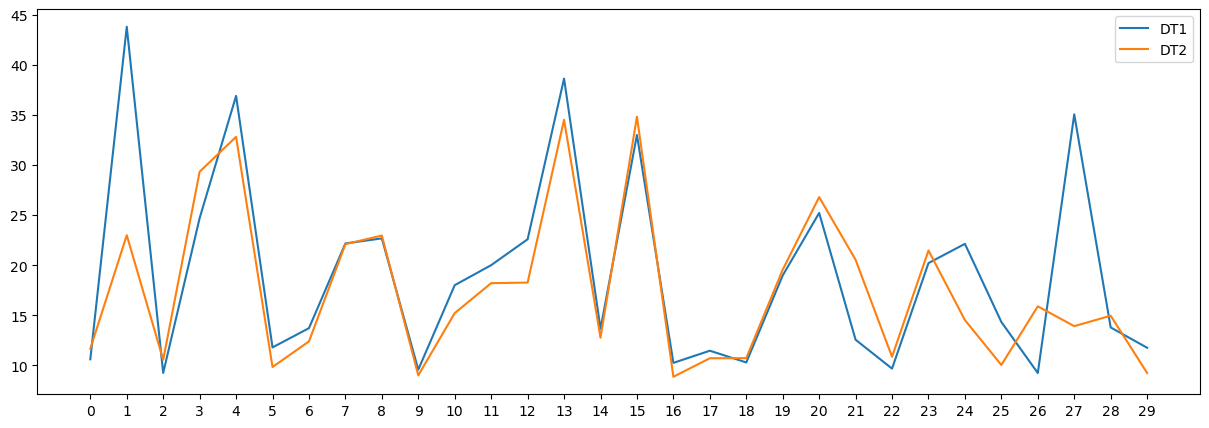

In [115]:
# repeated KFold cross-validation procedure
rcv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=101)
DTR1 = DecisionTreeRegressor(random_state=101)
DTR2 = DecisionTreeRegressor(random_state=101, max_depth=12, max_leaf_nodes=70)
mse1 = pd.DataFrame(-cross_val_score(DTR1, X, y, scoring='neg_mean_squared_error', cv=rcv), columns=['DT1'])
mse2 = pd.DataFrame(-cross_val_score(DTR2, X, y, scoring='neg_mean_squared_error', cv=rcv), columns=['DT2'])
# line chart on two sets of mse's
mse=pd.concat([mse1,mse2], axis=1)
mse.plot(kind='line', figsize=(15,5), xticks=range(30));

**Notes**

* With max_depth=12, max_leaf_nodes=70, the results improve somewhat.

In [121]:
# We will Apply feature selection to Dump of features that are not required

In [127]:
model = RandomForestRegressor(random_state=101)

model.fit(X_train, y_train)
# get feature_importances to see which features contributes the most
importances=model.feature_importances_
importances

array([0.03418455, 0.00143771, 0.00695434, 0.00078207, 0.02423692,
       0.40317579, 0.01441327, 0.05641811, 0.00351926, 0.01425918,
       0.01735944, 0.01139649, 0.41186285])

In [129]:
# dataframe for "perm_importance.importances"
FI=pd.DataFrame(importances, index=X_train.columns).T
FI

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.034185,0.001438,0.006954,0.000782,0.024237,0.403176,0.014413,0.056418,0.003519,0.014259,0.017359,0.011396,0.411863


<Axes: >

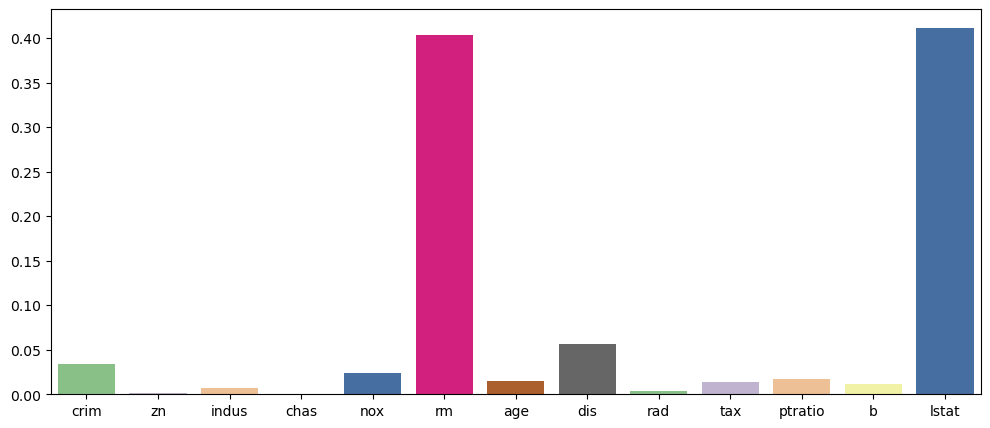

In [131]:
#Plot Searborn bar chart
plt.figure(figsize=(12,5))
sns.barplot(data=FI, palette='Accent')

In [159]:
# compute permutation_importance with test set (20 repeats) 
# Checks the MSE after training 
# If MSE increases removing, the feature was important
# .feature_importances_  “Which features did the tree use the most when building?”
#permutation_importance → “If I break this feature’s info, does the model get worse? If yes, it’s important.”
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=20, 
                                         scoring='neg_mean_squared_error', random_state=99)
perm_importance

{'importances_mean': array([2.04739349e+00, 2.05157247e-01, 9.41678614e-01, 1.17817971e-02,
        2.61043973e+00, 5.81068274e+01, 4.34333953e-01, 1.74979884e+01,
        1.44465882e-03, 1.58149251e+00, 3.78472363e+00, 7.35334994e-01,
        6.02197885e+01]),
 'importances_std': array([ 0.4582961 ,  0.05551782,  0.27713626,  0.02188106,  0.77882098,
        10.32415531,  0.40194222,  4.41024876,  0.18864107,  0.96490299,
         1.12981317,  0.3139076 , 15.18599038]),
 'importances': array([[ 1.61213539e+00,  1.89857061e+00,  2.29649992e+00,
          1.62036637e+00,  2.92129047e+00,  2.66811980e+00,
          2.26413424e+00,  1.42947086e+00,  1.46004484e+00,
          1.93056939e+00,  1.58831729e+00,  2.70063624e+00,
          2.34174435e+00,  2.13198088e+00,  2.22765224e+00,
          2.30232753e+00,  2.21653524e+00,  1.21957590e+00,
          1.69469859e+00,  2.42319963e+00],
        [ 1.33570843e-01,  2.23610627e-01,  2.99295353e-01,
          2.15455549e-01,  1.76530980e-01,  1

In [161]:
# dataframe for "perm_importance.importances"
PFI=pd.DataFrame(perm_importance.importances, index=X_test.columns).T
PFI.shape

(20, 13)

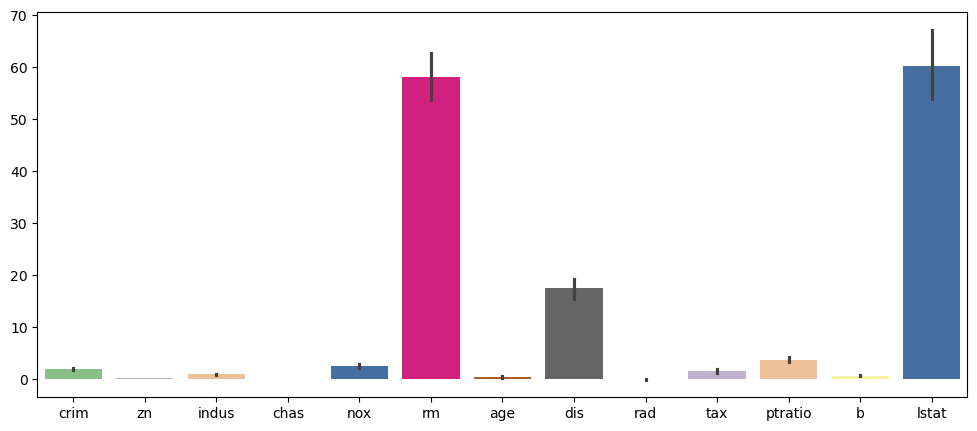

In [139]:
#Plot Searborn bar chart
plt.figure(figsize=(12,5))
sns.barplot(data=PFI,  palette='Accent');

In [143]:
# FRE with K-Fold CV for # of features selection with scoring: "negative MSE" 
rfe_cv = RFECV(model, cv=10, scoring='neg_mean_squared_error').fit(X_train,y_train)
# number of features
rfe_cv.n_features_

12

In [145]:
# what are features selected? Use "support_"
pd.DataFrame(rfe_cv.support_, index=X.columns).T

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,True,True,True,False,True,True,True,True,True,True,True,True,True


In [149]:
support=X_train.columns[rfe_cv.support_]
support

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat'],
      dtype='object')

In [151]:
# get 12 selected features
support=X_train.columns[rfe_cv.support_]
# select 12 features for modelling & evaluation
X_train_12=X_train[support]
X_test_12=X_test[support]
# re-run linear regression with the selected 11 features
RFR = RandomForestRegressor(random_state=101, n_estimators=100, max_depth=None)
RFR.fit(X_train_12, y_train)
print("MSE (12 features): ", MSE(y_test, RFR.predict(X_test_12)).round(3))
RFR.fit(X_train, y_train)
print("MSE (all features):", MSE(y_test, RFR.predict(X_test)).round(3))

MSE (12 features):  10.979
MSE (all features): 11.013


In [153]:
# ✅ Final Note:
# The Random Forest model using the 12 selected features performed slightly better (MSE = 10.979)
# compared to using all features (MSE = 11.013). 
# This indicates that feature selection helped reduce noise and improved generalization.
# We can proceed with the reduced model for a more efficient and interpretable solution.
